# Dinner Party – Grover's Algorithm with a `PhaseOracle`

A toy version of the classic constraint-satisfaction problem:

> You want to throw a dinner party with four friends – call them A, B, C and D. The catch:
>
> - At least one of the pairs `(A & C)` or `(B & D)` has to be there.
> - C and D can't be at the party at the same time (they had a bad break-up).
>
> Find every guest-list that works.

In Boolean terms: `((A & C) | (B & D)) & ~(C & D)`.

We use Grover's algorithm to **amplify** the satisfying assignments so they dominate the measurement statistics.

> **What changed since the original notebook?**
>
> | Old API (Qiskit ≤ 0.45) | New API |
> |---|---|
> | `from qiskit.algorithms import Grover, AmplificationProblem` | `pip install qiskit-algorithms` and `from qiskit_algorithms import ...` |
> | `Grover(quantum_instance=Aer.get_backend('qasm_simulator'))` | `Grover(sampler=StatevectorSampler())` (a V2 sampler primitive) |
> | `result.circuit_results[0]` | Same, but it's a list – the *last* element is what Grover settled on. |
>
> `PhaseOracle` itself still works (it has been re-implemented to no longer depend on the deprecated `tweedledum` library), but as of Qiskit 2.2 it is **deprecated** in favour of `PhaseOracleGate`. Expect to migrate this notebook to `PhaseOracleGate` once `qiskit-algorithms` adds support for it.
>
> ⚠️ **Heads-up about variable ordering.** `PhaseOracle` allocates qubits in the order the variables **first appear** in the expression. For our expression `((A & C) | (B & D)) & ~(C & D)` that is `(A, C, B, D)` – **not** alphabetical. Combined with Qiskit's little-endian bit display, the four characters in a measurement string are `D B C A` (from left to right).

In [3]:
#!pip install qiskit_algorithms
#import sys
#!{sys.executable} -m pip install qiskit_algorithms

In [4]:
# NOTE: `qiskit.algorithms` was removed in Qiskit 1.0. The Grover utilities
# were moved to a separate package: `qiskit-algorithms`.
#
#   pip install qiskit qiskit-algorithms qiskit-aer
#
# `PhaseOracle` is still part of `qiskit.circuit.library` (Qiskit 2.x reworked
# it so it no longer depends on the tweedledum package).
from qiskit.circuit.library import PhaseOracle
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_algorithms import Grover, AmplificationProblem

%matplotlib inline

## Solving the puzzle with Grover

We hand the Boolean expression to Grover via:

1. **`PhaseOracle`** – converts the expression into a quantum oracle that flips the phase of every satisfying assignment.
2. **`AmplificationProblem`** – wraps the oracle plus a python predicate that says whether a measured bitstring is a "good state".
3. **`Grover`** – picks how many iterations to run and then runs them through the supplied sampler.

Because the algorithm doesn't know in advance how many solutions there are, it tries increasing numbers of iterations until the predicate returns `True`.

In [5]:
oracle = PhaseOracle('((A & C) | (B & D)) & ~(C & D)')
problem = AmplificationProblem(
    oracle=oracle,
    is_good_state=oracle.evaluate_bitstring,
)

# In modern Qiskit, Grover takes a *sampler primitive* instead of a
# `quantum_instance`.  StatevectorSampler is the easy local choice; you can
# swap it for a noisy simulator or the IBM Quantum Sampler later.
sampler = StatevectorSampler(default_shots=1024)
grover = Grover(sampler=sampler)
result = grover.amplify(problem)

print("Top measurement (most likely satisfying assignment):", result.top_measurement)

Top measurement (most likely satisfying assignment): 1101


/var/folders/n9/38m8fw8j1flb3nhw8ld2ds5m0000gn/T/ipykernel_80598/2354492611.py:1: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  oracle = PhaseOracle('((A & C) | (B & D)) & ~(C & D)')


### Looking at the raw counts

Before plotting, let's print the raw measurement counts for the iteration Grover settled on. We expect the four satisfying assignments to dominate.

In [6]:
# `result.circuit_results` is a list of count dictionaries – one per Grover
# iteration that was tried. The last entry is the "best" one.
print(result.circuit_results[-1])

{'1100': 0.2626953125, '0011': 0.2197265625, '0111': 0.2421875, '1101': 0.275390625}


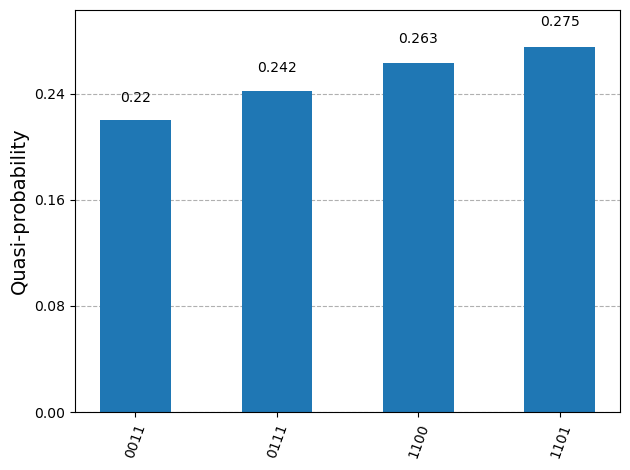

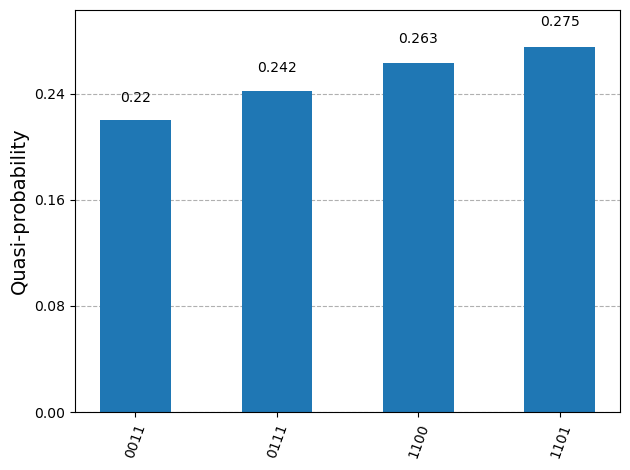

In [7]:
plot_histogram(result.circuit_results[-1])

### Reading the histogram

The histogram should show four peaks – one for each satisfying assignment – clearly above the "background" of the other 12 states. Below we map them back to the original story.

In [8]:
# Possible guests (variables A, B, C, D) → e.g.
#   A = James, B = Kirk, C = Lars, D = Rob
#
# Constraint   ((A & C) | (B & D)) & ~(C & D)
# means: at least one of the pairs (James+Lars) or (Kirk+Rob) must come,
# AND Lars and Rob can't be at the party together.
#
# Important: PhaseOracle assigns qubits in the order the variables FIRST
# APPEAR in the expression, which here is (A, C, B, D) — not alphabetical!
# Qiskit also prints bitstrings little-endian (qubit 0 on the right), so the
# displayed string is  D B C A.
#
# The four satisfying assignments (read as DBCA) are:
#   0011   →  A=1, C=1               →  James + Lars
#   0111   →  A=1, B=1, C=1          →  James + Kirk + Lars
#   1100   →  B=1, D=1               →  Kirk  + Rob
#   1101   →  A=1, B=1, D=1          →  James + Kirk + Rob
# Grover should amplify exactly these four bitstrings.

### Inspecting the full Grover result

`GroverResult` carries useful metadata: the most likely outcome, whether a "good state" was found, the number of iterations Grover decided to run, etc.

In [9]:
print(result)
print()
print("oracle_evaluation :", result.oracle_evaluation)  # True if good_state was found
print("top_measurement   :", result.top_measurement)
print("iterations tried  :", result.iterations)

{   'assignment': '1101',
    'circuit_results': [   {   '0011': 0.2197265625,
                               '0111': 0.2421875,
                               '1100': 0.2626953125,
                               '1101': 0.275390625}],
    'iterations': [1],
    'max_probability': 0.275390625,
    'oracle_evaluation': True,
    'top_measurement': '1101'}

oracle_evaluation : True
top_measurement   : 1101
iterations tried  : [1]


### Curious about `PhaseOracle`?

`PhaseOracle` builds a quantum oracle directly from a Boolean expression. Run the next cell to see its docstring.

In [10]:
help(PhaseOracle)

Help on class PhaseOracle in module qiskit.circuit.library.phase_oracle:

class PhaseOracle(qiskit.circuit.quantumcircuit.QuantumCircuit)
 |  PhaseOracle(
 |      expression: 'str | BooleanExpression',
 |      var_order: 'list[str] | None' = None
 |  ) -> 'None'
 |
 |  Phase Oracle.
 |
 |  The Phase Oracle object constructs circuits for any arbitrary
 |  input logical expressions. A logical expression is composed of logical operators
 |  `&` (logical `AND`), `|` (logical  `OR`),
 |  `~` (logical  `NOT`), and `^` (logical  `XOR`).
 |  as well as symbols for literals (variables).
 |  For example, `'a & b'`, and `(v0 | ~v1) & (~v2 & v3)`
 |  are both valid string representation of boolean logical expressions.
 |
 |  A phase oracle for a boolean function `f(x)` performs the following
 |  quantum operation:
 |
 |  .. math::
 |
 |          |x\rangle \mapsto (-1)^{f(x)}|x\rangle
 |
 |  For convenience, this oracle, in addition to parsing arbitrary logical expressions,
 |  also supports input 